In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

In [48]:
crocodile = pd.read_csv("../data/crocodile_dataset.csv")

In [49]:
crocodile['Age Class'].value_counts()

Age Class
Adult        510
Subadult     247
Juvenile     194
Hatchling     49
Name: count, dtype: int64

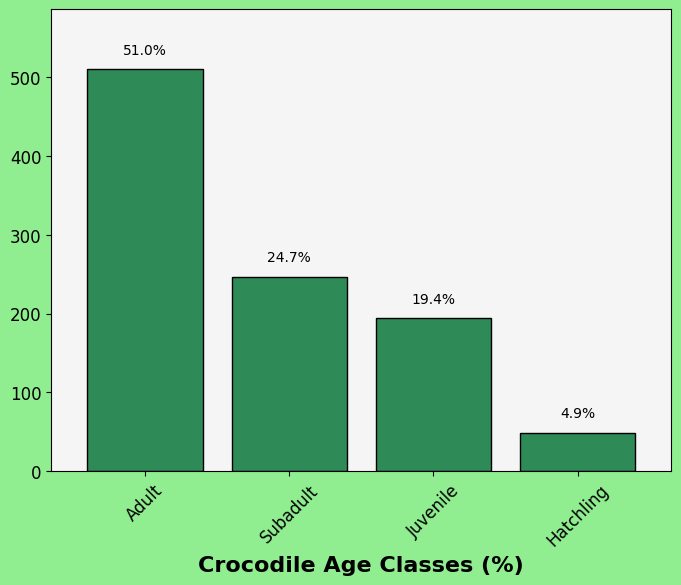

In [50]:
age_classes = crocodile['Age Class'].value_counts()
percentages = (age_classes / age_classes.sum() * 100).round(1)
plt.figure(facecolor='lightgreen', figsize=(8, 6))
ax = age_classes.plot(kind='bar', color='seagreen', width=0.8, edgecolor='black', fontsize=12)

ax.set_facecolor('whitesmoke')

ax.set_ylim(0, age_classes.max() * 1.15)

# add percentage labels
for i, (count, pct) in enumerate(zip(age_classes, percentages)):
    ax.text(i, count + (age_classes.max() * 0.03), f'{pct}%', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45)    
plt.xlabel('Crocodile Age Classes (%)', fontsize=16, fontweight='bold')
plt.show()

In [51]:
average_length = crocodile['Observed Length (m)'].mean()
print(average_length.round(2))

average_weight = crocodile['Observed Weight (kg)'].mean()
print(average_weight.round(2))

2.42
155.77


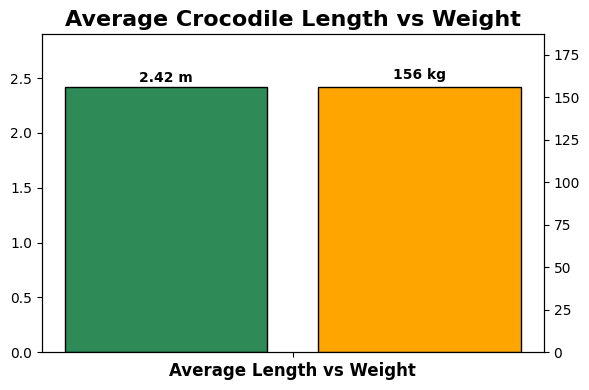

In [52]:
fig, ax1 = plt.subplots(figsize=(6,4))
ax2 = ax1.twinx()

x_length = 0
x_weight = 0.25

bar_width = 0.2

ax1.bar(x_length, average_length, color='seagreen', edgecolor='black', width=bar_width)
ax2.bar(x_weight, average_weight, color='orange', edgecolor='black', width=bar_width)

ax1.text(x_length, average_length + 0.05, f'{average_length:.2f} m', ha='center', fontsize=10, fontweight='bold')
ax2.text(x_weight, average_weight + 5, f'{average_weight:.0f} kg', ha='center', fontsize=10, fontweight='bold')

ax1.set_xticks([(x_length + x_weight)/2])
ax1.set_xticklabels(['Average Length vs Weight'], fontsize=12, fontweight='bold')

ax1.set_ylim(0, average_length * 1.2)
ax2.set_ylim(0, average_weight * 1.2)

plt.title('Average Crocodile Length vs Weight', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [53]:
top_length = crocodile['Observed Length (m)'].value_counts().nlargest(5)
print(top_length)

Observed Length (m)
2.26    11
2.76    10
2.52     8
2.81     8
2.63     8
Name: count, dtype: int64


In [54]:
# top_length.plot(figsize=(7,6), kind='barh', color='skyblue', edgecolor='black')
# plt.show()

In [55]:
habitat = crocodile['Habitat Type'].value_counts().nlargest()
print(habitat)

Habitat Type
Rivers                 165
Swamps                 156
Forest Swamps           57
Lakes                   54
Freshwater Wetlands     47
Name: count, dtype: int64


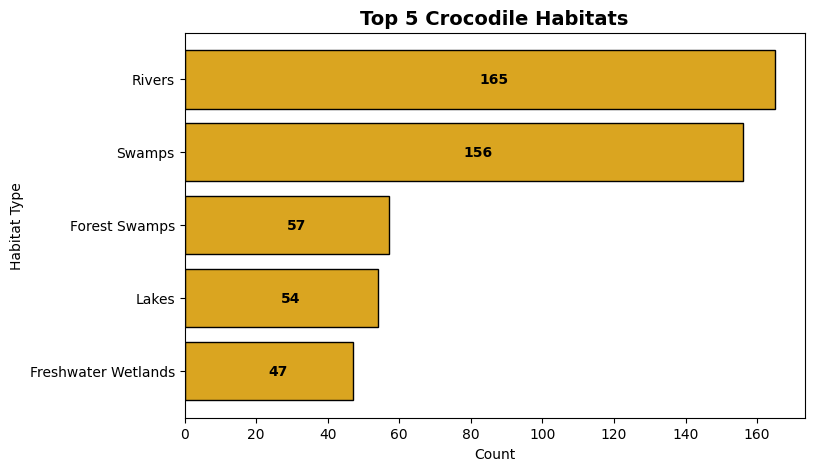

In [56]:
habitat = crocodile['Habitat Type'].value_counts().nlargest(5)
plt.figure(figsize=(8, 5))
bars = plt.barh(
    habitat.index,
    habitat.values,
    color= 'goldenrod',
    edgecolor='black',
)

plt.title('Top 5 Crocodile Habitats', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Habitat Type')

for bar in bars:
    plt.text(
        bar.get_width()/2,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black',
        fontweight='bold'
    )
plt.gca().invert_yaxis() # biggest is on top    
plt.show()

In [57]:
age_habitat = crocodile.groupby(['Habitat Type', 'Country/Region']).size().nlargest(10)
print(age_habitat)

Habitat Type         Country/Region   
Swamps               Cuba                 39
Rivers               Papua New Guinea     34
Freshwater Wetlands  Papua New Guinea     27
Estuarine Systems    Malaysia (Borneo)    24
Freshwater Marshes   Philippines          23
Rivers               Philippines          21
Flooded Savannas     Venezuela            20
Freshwater Wetlands  Cuba                 20
Large Rivers         Venezuela            20
Forest Swamps        Congo (DRC)          18
dtype: int64


In [58]:
cons_status = crocodile['Conservation Status'].value_counts()
print(cons_status)

Conservation Status
Least Concern            384
Critically Endangered    275
Vulnerable               170
Data Deficient           115
Endangered                56
Name: count, dtype: int64


C:\Users\SchadlMelani_3k1p0ca\AppData\Local\Temp\ipykernel_16896\1166584283.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


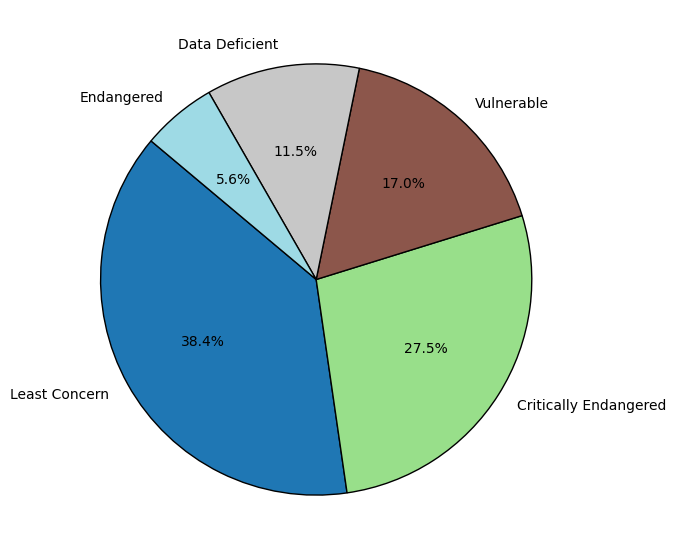

In [74]:
plt.figure(figsize=(7, 7))

cmap = cm.get_cmap('tab20')

colors = cmap(np.linspace(0, 1, len(cons_status)))

plt.pie(
    cons_status.values,
    labels=cons_status.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor' : 'black'}
)

plt.show()

In [60]:
384 / 1000 * 100

38.4

In [61]:
sci_name = crocodile['Scientific Name'].value_counts()
print(sci_name)

Scientific Name
Crocodylus novaeguineae    68
Crocodylus raninus         67
Crocodylus acutus          66
Crocodylus moreletii       64
Crocodylus rhombifer       59
Crocodylus intermedius     58
Crocodylus mindorensis     58
Crocodylus porosus         58
Osteolaemus tetraspis      57
Mecistops leptorhynchus    56
Mecistops cataphractus     55
Crocodylus suchus          52
Crocodylus halli           49
Osteolaemus osborni        48
Crocodylus niloticus       48
Crocodylus palustris       47
Crocodylus siamensis       45
Crocodylus johnstoni       45
Name: count, dtype: int64


In [62]:
sex = crocodile['Sex'].value_counts()
print(sex)

Sex
Unknown    354
Male       325
Female     321
Name: count, dtype: int64
